In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import os
import csv
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import pandas as pd

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_path = "/content/drive/MyDrive/similarity_rag/dataset/dataset_01/rag_dataset.tsv"

TOP_K = 3
BATCH_SIZE = 32
EPOCHS = 7
REFRESH_STEPS = 200
DB_BATCH_SIZE = 64

mapping = {"A":0,"C":1,"G":2,"T":3}

**one_hot** one-hot encodes DNA sequences.

In [5]:
def one_hot(seq, max_len):
    arr = np.zeros((max_len,4),dtype=np.float32)
    for i,c in enumerate(seq[:max_len]):
        if c in mapping:
            arr[i,mapping[c]] = 1
    return arr

Class **DNARAGDataset** defines a PyTorch Dataset wrapper for sequence pairs and targets.

In [6]:
class DNARAGDataset(Dataset):
    def __init__(self, pairs, targets, indices):
        self.pairs = pairs
        self.targets = targets
        self.indices = indices
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        return torch.tensor(self.pairs[idx], dtype=torch.float32), torch.tensor(self.targets[idx], dtype=torch.float32)


1. Class **SeqEncoder** is a convolutional neural network designed to extract high-level embeddings from DNA sequences represented as one-hot encoded arrays. It transforms variable-length sequences of nucleotides into fixed-size feature vectors suitable for downstream tasks, providing a compact representation of DNA sequences, encoding relevant patterns for similarity comparison or downstream regression tasks.

2. Class **CrossAttention** implements a multi-head attention mechanism that allows a query embedding to attend over a set of context embeddings. It uses 4 attention heads to capture relationships between the query and context features in different subspaces by expanding the query to sequence length 1 to match MultiheadAttention requirements and computes attention-weighted combinations of context vectors.

3. Class **DNARAG** implements a RAG-style regression model for predicting sequence similarity. It combines sequence embeddings with information retrieved from a database of known sequence pairs, enhancing regression accuracy by leveraging external sequence information, allowing the model to learn relational patterns rather than relying solely on individual sequence embeddings.

4. Class **DNANoRAG** implements a baseline model without retrieval. It uses only the SeqEncoder to transform input sequences into embeddings and an MLP to predict sequence similarity, providing a baseline to evaluate the effectiveness of retrieval-augmented predictions.

In [7]:
class SeqEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv1d(4, 64, 7, padding=3), nn.ReLU(), nn.Conv1d(64, 64, 5, padding=2), nn.ReLU(), nn.Conv1d(64, 128, 3, padding=1), nn.ReLU())
        self.pool = nn.AdaptiveMaxPool1d(1)
    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        return x


class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=4, batch_first=True)
    def forward(self, query, context):
        query = query.unsqueeze(1)
        out, _ = self.attn(query, context, context)
        return out.squeeze(1)


class DNARAG(nn.Module):
    def __init__(self, database_pairs, db_batch_size=64, top_k=3):
        super().__init__()
        self.encoder = SeqEncoder()
        self.cross_attn = CrossAttention(128)
        self.head = nn.Sequential(
            nn.Linear(128*2, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.database = torch.tensor(database_pairs, dtype=torch.float32)
        self.db_embeddings = None
        self.db_batch_size = db_batch_size
        self.TOP_K = top_k

    def encode_pairs(self, pairs):
        return self.encoder(pairs)

    def refresh_database(self):
        self.encoder.eval()
        emb_list = []
        with torch.no_grad():
            for i in range(0, len(self.database), self.db_batch_size):
                batch = self.database[i:i+self.db_batch_size].to(device)
                emb = self.encode_pairs(batch)
                emb_list.append(emb.cpu())
        self.db_embeddings = torch.cat(emb_list, dim=0)

    def retrieve(self, query_emb):
        sims_list = []
        for i in range(0, len(self.db_embeddings), self.db_batch_size):
            db_batch = self.db_embeddings[i:i+self.db_batch_size].to(device)
            sims = torch.matmul(query_emb, db_batch.T)
            sims_list.append(sims.cpu())
        sims = torch.cat(sims_list, dim=1)
        topk = torch.topk(sims, self.TOP_K, dim=1)
        retrieved = self.db_embeddings[topk.indices].to(device)
        return retrieved

    def forward(self, pairs):
        query_emb = self.encode_pairs(pairs)
        retrieved = self.retrieve(query_emb)
        context = self.cross_attn(query_emb, retrieved)
        x = torch.cat([query_emb, context], dim=1)
        return self.head(x).squeeze()


class DNANoRAG(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SeqEncoder()
        self.head = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, pairs):
        query_emb = self.encoder(pairs)
        return self.head(query_emb).squeeze()


**train_model** is a training function wich tracks huber loss on training and validation sets with optional database embedding refresh for RAG.

In [8]:
def train_model(model, train_loader, val_loader, epochs=7, refresh_db=False):
    optimizer = optim.Adam(model.parameters(), lr=2e-4)
    loss_fn = nn.HuberLoss()
    if refresh_db:
        model.refresh_database()
    train_losses, val_losses = [], []

    step = 0
    for epoch in range(epochs):
        model.train()
        running = 0
        for pairs_batch, target in train_loader:
            step += 1
            pairs_batch, target = pairs_batch.to(device), target.to(device)
            optimizer.zero_grad()
            pred = model(pairs_batch)
            loss = loss_fn(pred, target)
            loss.backward()
            optimizer.step()
            running += loss.item()
            if refresh_db and step % REFRESH_STEPS == 0:
                model.refresh_database()
        train_loss = running / len(train_loader)

        model.eval()
        running_val = 0
        with torch.no_grad():
            for pairs_batch, target in val_loader:
                pairs_batch, target = pairs_batch.to(device), target.to(device)
                pred = model(pairs_batch)
                loss = loss_fn(pred, target)
                running_val += loss.item()
        val_loss = running_val / len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1} | train {train_loss:.4f} | val {val_loss:.4f}")
    return train_losses, val_losses


**evaluate_model** evaluates models using MAE, RMSE, R², MRE, Pearson, Spearman, and optionally top-K cosine similarity for RAG.

In [9]:
def evaluate_model(model, loader, top_k_cosine=False):
    model.eval()
    predictions, targets_list = [], []
    all_query_embs = []

    with torch.no_grad():
        for pairs_batch, target in loader:
            pairs_batch, target = pairs_batch.to(device), target.to(device)
            pred = model(pairs_batch)
            predictions.extend(pred.cpu().numpy())
            targets_list.extend(target.cpu().numpy())
            if hasattr(model, 'encode_pairs'):
                query_emb = model.encode_pairs(pairs_batch)
                all_query_embs.append(query_emb.cpu())

    y_true = np.array(targets_list)
    y_pred = np.array(predictions)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res/ss_tot
    mre = np.mean(np.abs((y_true - y_pred)/(y_true + 1e-8)))
    pearson_corr = pearsonr(y_true, y_pred)[0]
    spearman_corr = spearmanr(y_true, y_pred)[0]

    results = {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "mre": mre,
        "pearson": pearson_corr,
        "spearman": spearman_corr
    }

    if top_k_cosine and hasattr(model, 'db_embeddings'):
        query_embs = torch.cat(all_query_embs, dim=0)
        query_emb_norm = query_embs / query_embs.norm(dim=1, keepdim=True)
        db_emb_norm = model.db_embeddings / model.db_embeddings.norm(dim=1, keepdim=True)
        sims = torch.matmul(query_emb_norm, db_emb_norm.T)
        topk_values, _ = torch.topk(sims, model.TOP_K, dim=1)
        results["topk_cosine"] = topk_values.mean().item()

    return results, y_true, y_pred


Loading the dataset, computing maximum sequence length, one-hot encoding DNA sequences, splitting data into train, validation, and test sets, and wrapping them in PyTorch DataLoaders.

In [10]:
rows = []
with open(data_path) as f:
    reader = csv.DictReader(f, delimiter="\t")
    for r in reader:
        rows.append(r)
print("Total pairs:", len(rows))

# Compute maximum sequence length
max_len = max(
    max(len(r["query_seq1"]), len(r["query_seq2"]),
        len(r["retrieved_seq1"]), len(r["retrieved_seq2"]))
    for r in rows
)
print("Max sequence length:", max_len)

# One-hot encode sequences
pairs, targets = [], []
for r in rows:
    q1 = one_hot(r["query_seq1"], max_len)
    q2 = one_hot(r["query_seq2"], max_len)
    r1 = one_hot(r["retrieved_seq1"], max_len)
    r2 = one_hot(r["retrieved_seq2"], max_len)
    pair = np.concatenate([q1,q2,r1,r2], axis=0)
    pairs.append(pair)
    targets.append(float(r["hsp_identity"])/100.0)

pairs = np.array(pairs)
targets = np.array(targets, dtype=np.float32)

train_idx, temp_idx = train_test_split(np.arange(len(pairs)), test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_ds = DNARAGDataset(pairs, targets, train_idx)
val_ds   = DNARAGDataset(pairs, targets, val_idx)
test_ds  = DNARAGDataset(pairs, targets, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)


Total pairs: 19900
Max sequence length: 1553


Training the baseline model without RAG and the RAG model with database retrieval.

In [11]:
print("Training Baseline...")
baseline_model = DNANoRAG().to(device)
baseline_train_losses, baseline_val_losses = train_model(baseline_model, train_loader, val_loader, epochs=EPOCHS)

print("Training RAG...")
rag_model = DNARAG(pairs, db_batch_size=DB_BATCH_SIZE, top_k=TOP_K).to(device)
rag_train_losses, rag_val_losses = train_model(rag_model, train_loader, val_loader, epochs=EPOCHS, refresh_db=True)


Training Baseline...
Epoch 1 | train 0.0158 | val 0.0018
Epoch 2 | train 0.0014 | val 0.0011
Epoch 3 | train 0.0008 | val 0.0005
Epoch 4 | train 0.0004 | val 0.0002
Epoch 5 | train 0.0002 | val 0.0003
Epoch 6 | train 0.0002 | val 0.0002
Epoch 7 | train 0.0002 | val 0.0001
Training RAG...
Epoch 1 | train 0.0131 | val 0.0017
Epoch 2 | train 0.0017 | val 0.0016
Epoch 3 | train 0.0016 | val 0.0016
Epoch 4 | train 0.0015 | val 0.0013
Epoch 5 | train 0.0010 | val 0.0008
Epoch 6 | train 0.0004 | val 0.0002
Epoch 7 | train 0.0003 | val 0.0002


Visualizing training and validation loss for both baseline and RAG models across epochs.

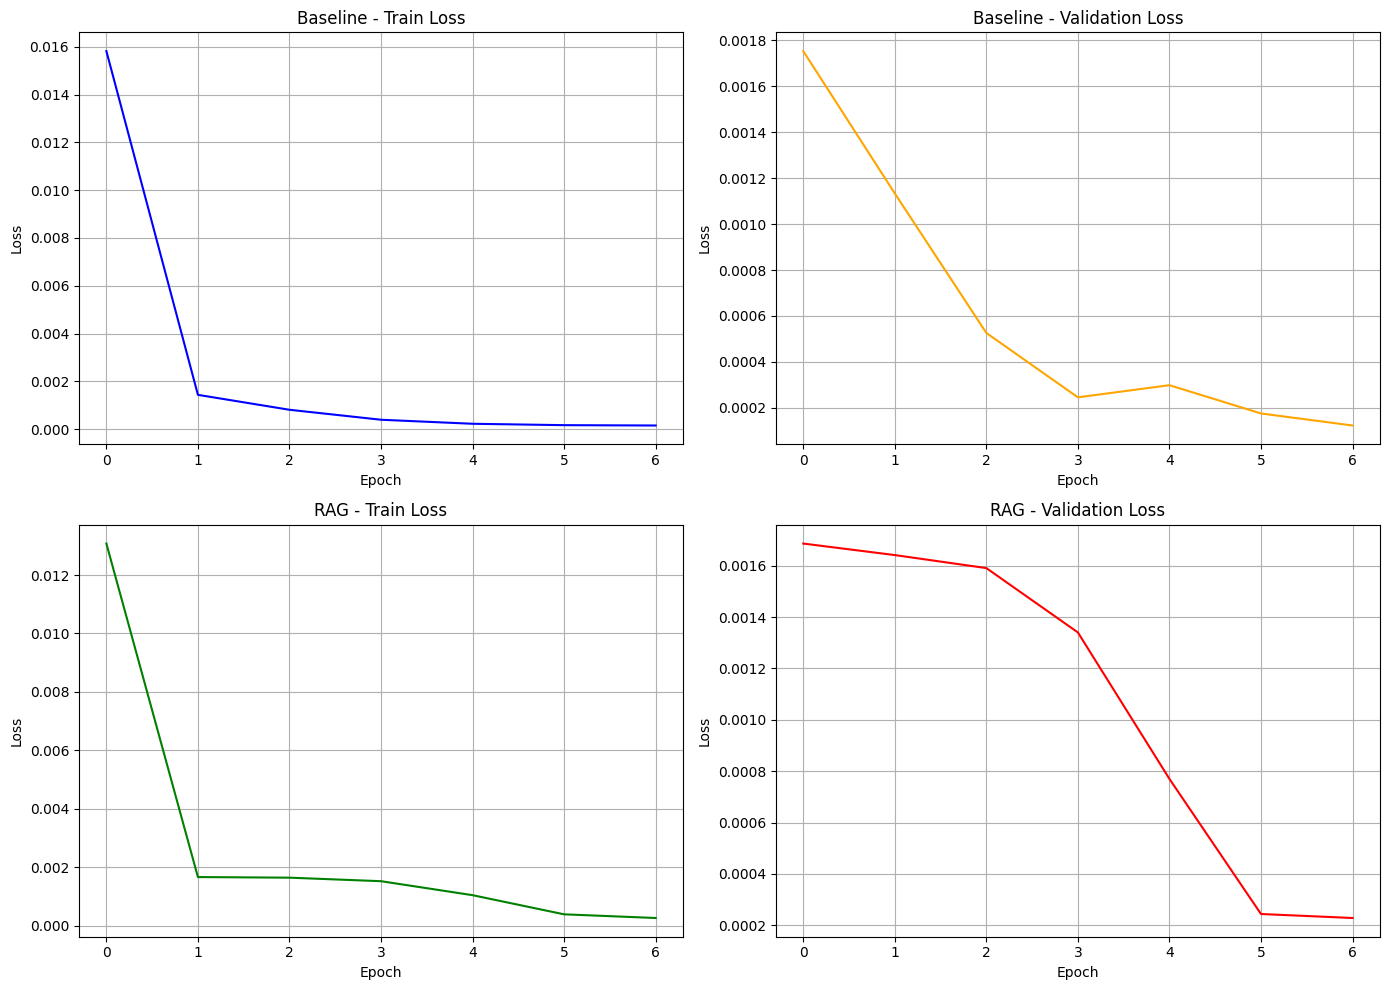

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes[0,0].plot(baseline_train_losses, color='blue')
axes[0,0].set_title("Baseline - Train Loss")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].grid(True)

axes[0,1].plot(baseline_val_losses, color='orange')
axes[0,1].set_title("Baseline - Validation Loss")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Loss")
axes[0,1].grid(True)

axes[1,0].plot(rag_train_losses, color='green')
axes[1,0].set_title("RAG - Train Loss")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Loss")
axes[1,0].grid(True)

axes[1,1].plot(rag_val_losses, color='red')
axes[1,1].set_title("RAG - Validation Loss")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Loss")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

Evaluating baseline and RAG models and displaying results.

In [13]:
baseline_res, y_true, y_pred_baseline = evaluate_model(baseline_model, test_loader)
rag_res, y_true, y_pred_rag = evaluate_model(rag_model, test_loader, top_k_cosine=True)

results_dict = {
    "Metric": ["MAE", "RMSE", "R^2", "MRE", "Pearson", "Spearman", "Top-K Cosine"],
    "Baseline": [
        round(baseline_res["mae"], 4),
        round(baseline_res["rmse"], 4),
        round(baseline_res["r2"], 4),
        round(baseline_res["mre"], 4),
        round(baseline_res["pearson"], 4),
        round(baseline_res["spearman"], 4),
        "-"
    ],
    "RAG": [
        round(rag_res["mae"], 4),
        round(rag_res["rmse"], 4),
        round(rag_res["r2"], 4),
        round(rag_res["mre"], 4),
        round(rag_res["pearson"], 4),
        round(rag_res["spearman"], 4),
        round(rag_res.get("topk_cosine", 0), 4)
    ]
}

df_results = pd.DataFrame(results_dict)
display(df_results)


,Metric,Baseline,RAG
0,MAE,0.0104,0.0162
1,RMSE,0.0159,0.0224
2,R^2,0.9299,0.8604
3,MRE,0.0118,0.0184
4,Pearson,0.9673,0.9374
5,Spearman,0.9622,0.9341
6,Top-K Cosine,-,0.9998


Plotting residuals to visualize prediction errors.

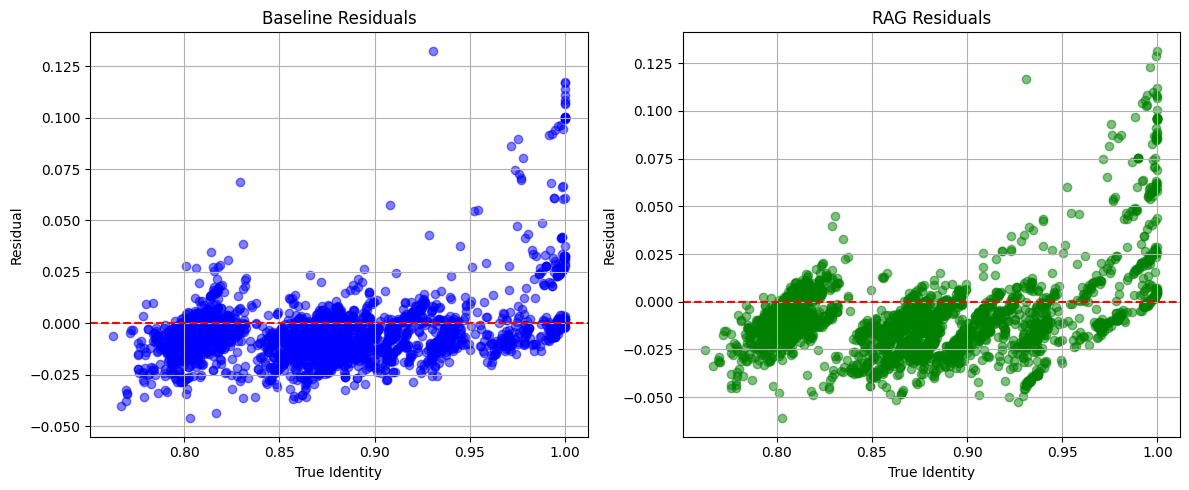

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(y_true, y_true - y_pred_baseline, alpha=0.5, color='blue')
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel("True Identity")
axes[0].set_ylabel("Residual")
axes[0].set_title("Baseline Residuals")
axes[0].grid(True)

axes[1].scatter(y_true, y_true - y_pred_rag, alpha=0.5, color='green')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("True Identity")
axes[1].set_ylabel("Residual")
axes[1].set_title("RAG Residuals")
axes[1].grid(True)

plt.tight_layout()
plt.show()


Plotying predicted vs. true similarity scatterplots for baseline and RAG models to evaluate prediction quality visually.

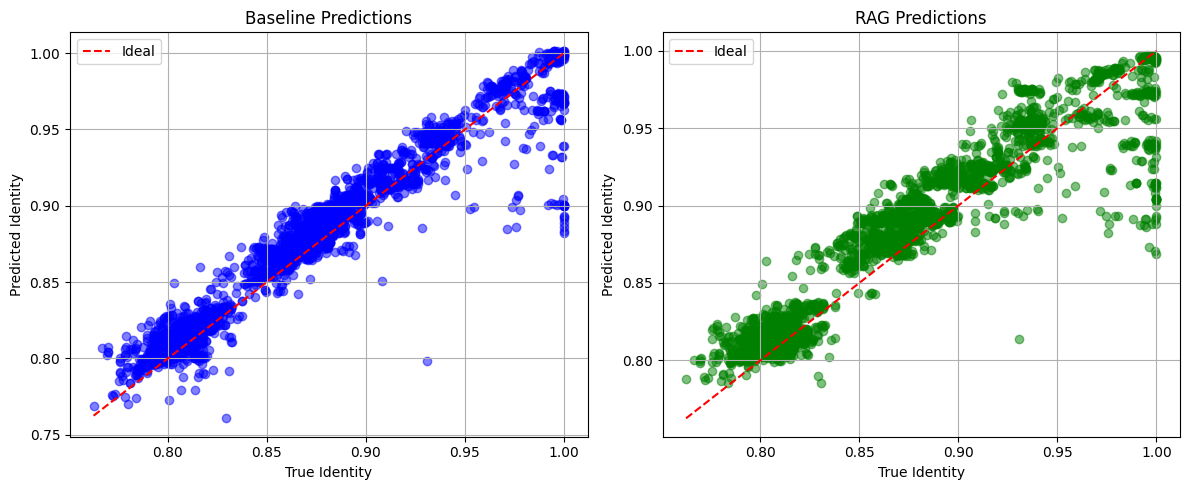

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(y_true, y_pred_baseline, alpha=0.5, color='blue')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label="Ideal")
axes[0].set_xlabel("True Identity")
axes[0].set_ylabel("Predicted Identity")
axes[0].set_title("Baseline Predictions")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(y_true, y_pred_rag, alpha=0.5, color='green')
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label="Ideal")
axes[1].set_xlabel("True Identity")
axes[1].set_ylabel("Predicted Identity")
axes[1].set_title("RAG Predictions")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
